### Standard LR Model with feature engineered data - Fine Tuned

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

import optuna
import lime.lime_tabular
import shap
from IPython.display import display, HTML

/Users/amalshar/miniforge3/envs/mlenv64/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = '/Users/amalshar/Desktop/USD/Fall 2025/Data Analysis/Final Project/daily_2025_engineered_data.csv'
TARGET = 'DailyAQI'

BASE_FEATURES = ['CO', 'SO2', 'NO2', 'O3', 'PM25',
                 'BarometricPressure', 'Temperature', 'WindResultant']

ENG_FEATURES = [
    'AQI_lag_1','AQI_lag_3','AQI_lag_7',
    'AQI_roll_3','AQI_roll_7',
    'CO_roll_3','CO_roll_7','NO2_roll_3','NO2_roll_7',
    'PM25_roll_3','PM25_roll_7','O3_roll_3','O3_roll_7',
    'month','dayofweek','is_weekend','dayofyear',
    'PM25xTemp','NO2xWind'
]

FEATURES = BASE_FEATURES + ENG_FEATURES

# %%
df = pd.read_csv(DATA_PATH)
df['Date Local'] = pd.to_datetime(df['Date Local'], errors='coerce')

# Drop rows missing features or target
df = df.dropna(subset=FEATURES + [TARGET]).copy()

# Sort by time to respect temporal structure
df = df.sort_values('Date Local').reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Date range:", df['Date Local'].min(), "->", df['Date Local'].max())


Rows after cleaning: 91740
Date range: 2025-01-01 00:00:00 -> 2025-07-01 00:00:00


In [3]:
X = df[FEATURES]
y = df[TARGET]

# Use last 20% as test set
n_total = len(df)
test_size = int(0.2 * n_total)

X_trainval = X.iloc[:-test_size].copy()
y_trainval = y.iloc[:-test_size].copy()

X_test = X.iloc[-test_size:].copy()
y_test = y.iloc[-test_size:].copy()

print(f"Train+Val size: {len(X_trainval)}, Test size: {len(X_test)}")


Train+Val size: 73392, Test size: 18348


In [4]:
def create_pipeline(alpha: float) -> Pipeline:
    """Create a Ridge regression pipeline with scaling."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42))
    ])
    return pipe

N_SPLITS = 3
N_TRIALS = 20  # increase if you want a deeper search

def objective(trial):
    # log-uniform search over alpha
    alpha = trial.suggest_float('alpha', 1e-4, 100.0, log=True)

    pipe = create_pipeline(alpha)
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    rmses = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_trainval)):
        X_tr, X_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

        pipe.fit(X_tr, y_tr)
        y_val_pred = pipe.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        rmses.append(rmse)

    mean_rmse = float(np.mean(rmses))
    print(f"Trial {trial.number}: alpha={alpha:.5f} | mean CV RMSE={mean_rmse:.3f}")
    return mean_rmse


In [5]:
study = optuna.create_study(direction='minimize', study_name='ridge_aqi_feature_engineered')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)

[I 2025-11-25 15:52:04,071] A new study created in memory with name: ridge_aqi_feature_engineered
Best trial: 0. Best value: 9.80089:   5%|▌         | 1/20 [00:00<00:02,  8.81it/s]

Trial 0: alpha=0.03773 | mean CV RMSE=9.801
[I 2025-11-25 15:52:04,197] Trial 0 finished with value: 9.800893564759726 and parameters: {'alpha': 0.037733532428721225}. Best is trial 0 with value: 9.800893564759726.


Best trial: 0. Best value: 9.80089:  10%|█         | 2/20 [00:00<00:02,  8.69it/s]

Trial 1: alpha=2.14314 | mean CV RMSE=9.802
[I 2025-11-25 15:52:04,331] Trial 1 finished with value: 9.802206287100205 and parameters: {'alpha': 2.143136865880582}. Best is trial 0 with value: 9.800893564759726.


Best trial: 0. Best value: 9.80089:  20%|██        | 4/20 [00:00<00:01, 10.61it/s]

...

Trial 16: alpha=0.00011 | mean CV RMSE=9.801
[I 2025-11-25 15:52:05,590] Trial 16 finished with value: 9.800871372339648 and parameters: {'alpha': 0.00010519503785128672}. Best is trial 16 with value: 9.800871372339648.


Best trial: 16. Best value: 9.80087:  90%|█████████ | 18/20 [00:01<00:00, 11.90it/s]

Trial 17: alpha=0.17176 | mean CV RMSE=9.801
[I 2025-11-25 15:52:05,656] Trial 17 finished with value: 9.800972979183362 and parameters: {'alpha': 0.17175947077390424}. Best is trial 16 with value: 9.800871372339648.
Trial 18: alpha=0.00158 | mean CV RMSE=9.801
[I 2025-11-25 15:52:05,752] Trial 18 finished with value: 9.800872238609928 and parameters: {'alpha': 0.00157544562020423}. Best is trial 16 with value: 9.800871372339648.


Best trial: 19. Best value: 9.80087: 100%|██████████| 20/20 [00:01<00:00, 11.60it/s]

Trial 19: alpha=0.00010 | mean CV RMSE=9.801
[I 2025-11-25 15:52:05,825] Trial 19 finished with value: 9.800871370421715 and parameters: {'alpha': 0.00010193977548038409}. Best is trial 19 with value: 9.800871370421715.

Best trial:
  RMSE: 9.800871370421715
  Params: {'alpha': 0.00010193977548038409}


Best alpha from Optuna: 0.00010193977548038409
Tuned Ridge on Test -> MSE: 34.834 | RMSE: 5.902 | MAE: 3.343 | MAPE: 127820.98% | R²: 0.956


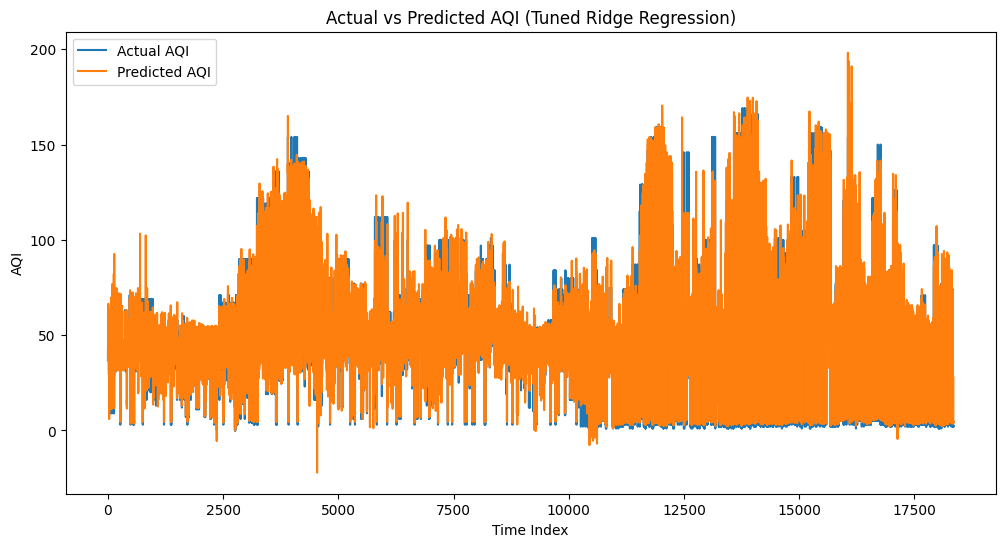

In [6]:
best_alpha = study.best_params['alpha']
print("Best alpha from Optuna:", best_alpha)

lr_pipe = create_pipeline(best_alpha)
lr_pipe.fit(X_trainval, y_trainval)

# %%
y_pred = lr_pipe.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-6))) * 100
r2   = r2_score(y_test, y_pred)

print(f"Tuned Ridge on Test -> MSE: {mse:.3f} | RMSE: {rmse:.3f} | "
      f"MAE: {mae:.3f} | MAPE: {mape:.2f}% | R²: {r2:.3f}")

# %%
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual AQI')
plt.plot(y_pred, label='Predicted AQI')
plt.title('Actual vs Predicted AQI (Tuned Ridge Regression)')
plt.xlabel('Time Index'); plt.ylabel('AQI'); plt.legend(); plt.show()



Top 15 Feature Coefficients:
        Feature  Coefficient
11   AQI_roll_3    59.534185
8     AQI_lag_1   -22.336236
17  PM25_roll_3   -14.941570
4          PM25    12.725823
9     AQI_lag_3   -10.888227
19    O3_roll_3    -5.815924
3            O3     4.931870
12   AQI_roll_7     4.042775
18  PM25_roll_7     1.549686
25    PM25xTemp     1.526267
10    AQI_lag_7    -1.142460
15   NO2_roll_3    -1.088807
2           NO2     0.978989
20    O3_roll_7     0.948373
0            CO    -0.761456


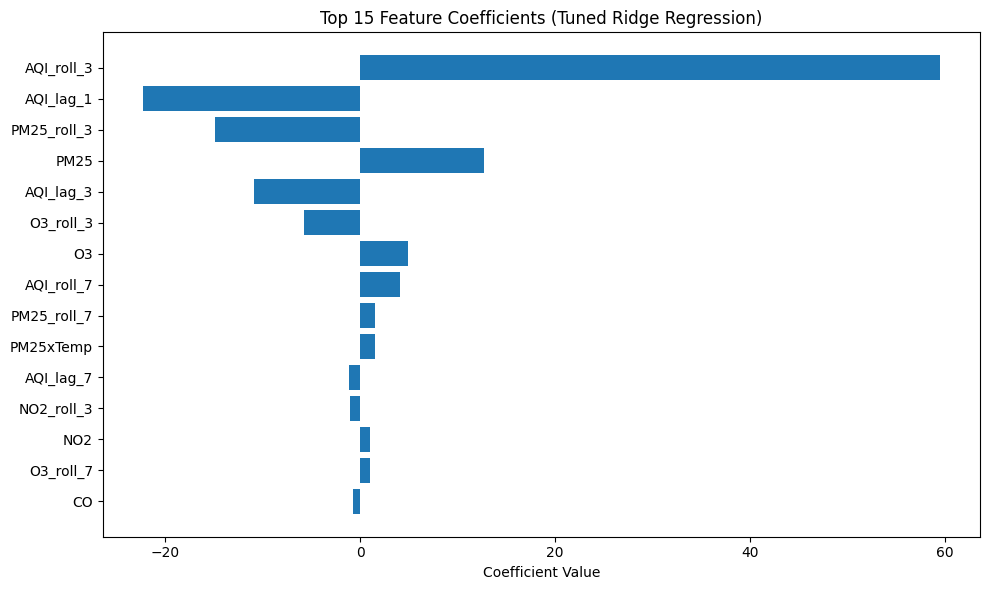

In [7]:
ridge_model = lr_pipe.named_steps['ridge']

coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': ridge_model.coef_
})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print("\nTop 15 Feature Coefficients:")
print(coef_df.head(15))

# %%
plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'][:15], coef_df['Coefficient'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Coefficients (Tuned Ridge Regression)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()



Permutation Feature Importance (R² drop):
        Feature  Importance (ΔR²)
11   AQI_roll_3          6.166542
8     AQI_lag_1          0.808771
17  PM25_roll_3          0.254810
9     AQI_lag_3          0.184944
4          PM25          0.184563
19    O3_roll_3          0.059218
3            O3          0.048924
12   AQI_roll_7          0.031115
18  PM25_roll_7          0.002920
25    PM25xTemp          0.002466
2           NO2          0.002340
20    O3_roll_7          0.001836
15   NO2_roll_3          0.001738
10    AQI_lag_7          0.001059
23   is_weekend          0.000297


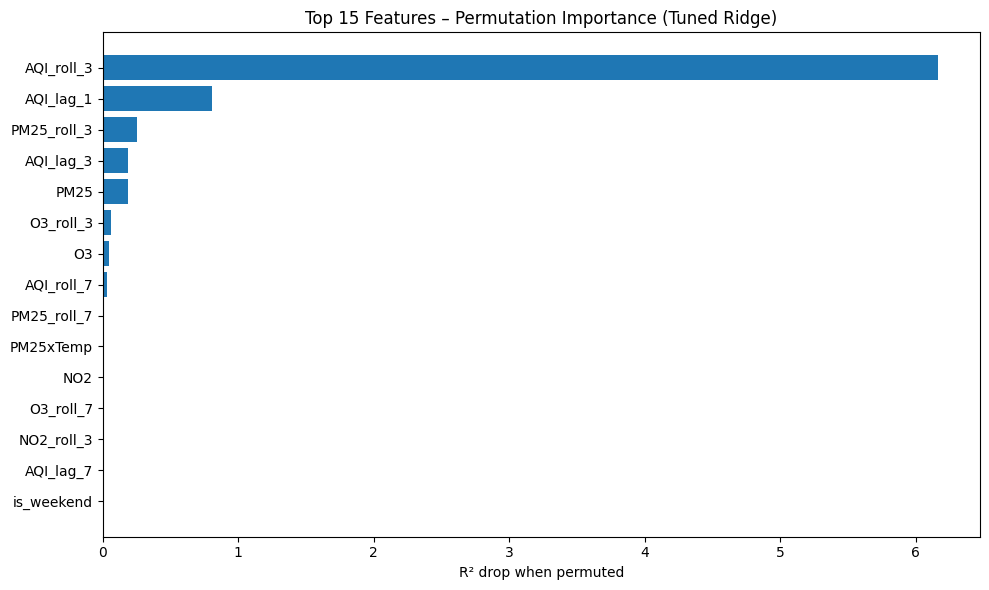

In [8]:
perm_result = permutation_importance(
    estimator=lr_pipe,
    X=X_test,
    y=y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

perm_importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance (ΔR²)': perm_result.importances_mean
}).sort_values('Importance (ΔR²)', ascending=False)

print("\nPermutation Feature Importance (R² drop):")
print(perm_importance_df.head(15))

# %%
plt.figure(figsize=(10,6))
plt.barh(perm_importance_df['Feature'][:15], perm_importance_df['Importance (ΔR²)'][:15])
plt.gca().invert_yaxis()
plt.xlabel('R² drop when permuted')
plt.title('Top 15 Features – Permutation Importance (Tuned Ridge)')
plt.tight_layout()
plt.show()


In [9]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_trainval.values,
    feature_names=FEATURES,
    mode='regression'
)

i = 0  # index of the test instance to explain
exp = lime_explainer.explain_instance(
    data_row=X_test.values[i],
    predict_fn=lr_pipe.predict,
    num_features=10
)

# Display LIME explanation
try:
    exp.show_in_notebook(show_table=True)
except Exception:
    display(HTML(exp.as_html()))

with open("exp14_lr_lime_explanation.html", "w") as f:
    f.write(exp.as_html())


/Users/amalshar/miniforge3/envs/mlenv64/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 50/50 [00:01<00:00, 43.96it/s]


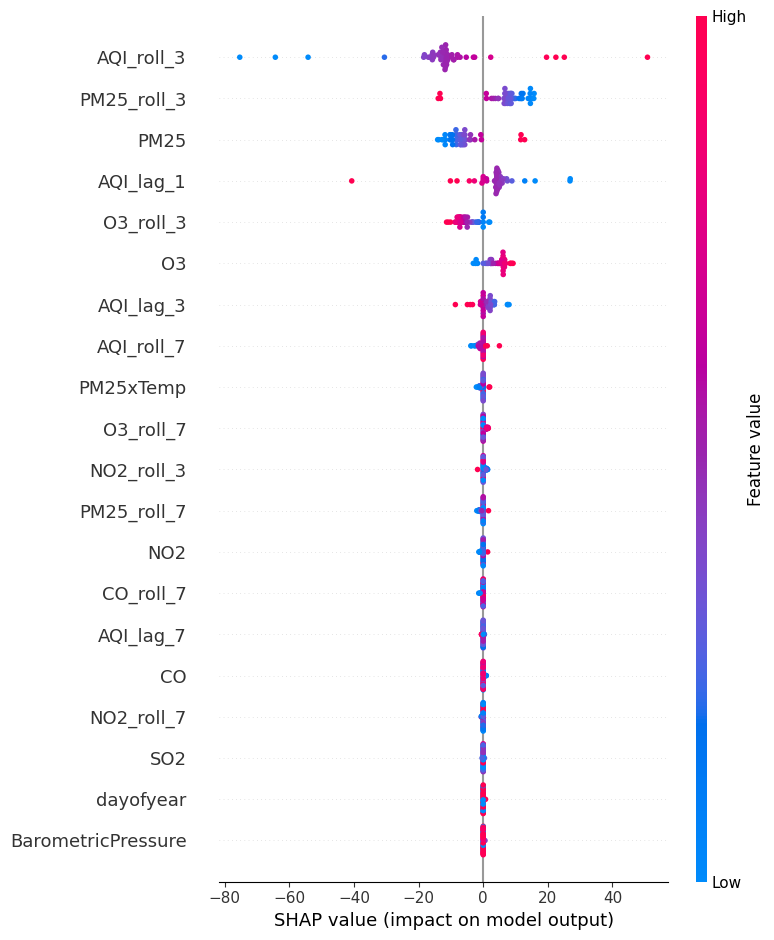

In [11]:
# Use a background sample for SHAP kernel explainer
X_background = X_trainval.sample(n=min(200, len(X_trainval)), random_state=42)

# Define a wrapper that SHAP can call
def predict_fn(data):
    # data comes as a numpy array → convert to DataFrame for pipeline
    df_tmp = pd.DataFrame(data, columns=FEATURES)
    return lr_pipe.predict(df_tmp)

# Create KernelExplainer
shap_explainer = shap.KernelExplainer(predict_fn, X_background)

# Take a small sample from test set
X_test_sample = X_test.iloc[:50]

# Compute SHAP values (nsamples controls runtime)
shap_values = shap_explainer.shap_values(X_test_sample, nsamples=200)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test_sample, feature_names=FEATURES)
